AI-QSAR model for carcinogenicity: single task classification model

Author: Chi-Yun Chen; Date created: Dec.11.2025
Description: Neural network

##Install necessary libraries

In [1]:
!pip install --upgrade pip

Defaulting to user installation because normal site-packages is not writeable


In [2]:
# Install python pacakges
!pip install -q rdkit-pypi==2023.3.1b1
!pip install scikit-optimize==0.10.2
!pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [3]:
#Install basic python pcakges
import pandas as pd
import numpy as np
import seaborn as sns
import time

# Molecular Descriptors Calculation
from rdkit import Chem
from rdkit.Chem import AllChem, MACCSkeys, Descriptors, DataStructs
from rdkit.DataStructs import ExplicitBitVect
from rdkit.ML.Descriptors import MoleculeDescriptors

# Modeling
from sklearn.preprocessing import MinMaxScaler      

# Import the SMILES contained dataset

In [4]:
df = pd.read_csv('SMILES_cancer df.csv')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 957 entries, 0 to 956
Data columns (total 84 columns):
 #   Column                                             Non-Null Count  Dtype 
---  ------                                             --------------  ----- 
 0   CAS                                                957 non-null    object
 1   Alimentary system                                  957 non-null    int64 
 2   Endocrine system                                   957 non-null    int64 
 3   Exocrine system                                    957 non-null    int64 
 4   Haematolymphoid system                             957 non-null    int64 
 5   Hepatobiliary system                               957 non-null    int64 
 6   Reproductive system                                957 non-null    int64 
 7   Respiratory system                                 957 non-null    int64 
 8   Skin and soft tissue                               957 non-null    int64 
 9   Special Senses System

# Split dataframe to X and y
Separate X into CAS and in vitro assays

In [6]:
# Y label: Organ systems
# Extracting the second to the tenth columns (index 1 to 9)
Y = df.iloc[:, 1:11]
Y.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 957 entries, 0 to 956
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Alimentary system       957 non-null    int64
 1   Endocrine system        957 non-null    int64
 2   Exocrine system         957 non-null    int64
 3   Haematolymphoid system  957 non-null    int64
 4   Hepatobiliary system    957 non-null    int64
 5   Reproductive system     957 non-null    int64
 6   Respiratory system      957 non-null    int64
 7   Skin and soft tissue    957 non-null    int64
 8   Special Senses System   957 non-null    int64
 9   Urinary system          957 non-null    int64
dtypes: int64(10)
memory usage: 74.9 KB


In [7]:
duplicates = df[df.duplicated(subset='SMILES', keep=False)]

# Show the removed chemicals (duplicates)
print(duplicates)

            CAS  Alimentary system  Endocrine system  Exocrine system  \
23     156-59-2                  0                 0                0   
24     156-60-5                  0                 0                0   
47   60348-60-9                  0                 0                0   
652  12789-03-6                  0                 1                0   
661    319-84-6                  0                 0                0   
662    319-85-7                  0                 0                0   
663  32534-81-9                  0                 1                0   
675     60-57-1                  0                 0                0   
676    608-73-1                  0                 0                0   
687     72-20-8                  0                 0                0   
867     57-74-9                  0                 0                0   
869     58-89-9                  0                 0                0   

     Haematolymphoid system  Hepatobiliary system 

# Check and remove the Y of duplicate SMILES
Since these duplicates contain different y and in vitro data, we need to remove all the duplicated chemicals (n = 12) from the original dataframe

In [8]:
# Filter out rows from df where the SMILES column matches any SMILES in duplicates
df_finalized = df[~df['CAS'].isin(duplicates['CAS'])]
df_finalized = df_finalized.reset_index(drop=True)
df_finalized.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 945 entries, 0 to 944
Data columns (total 84 columns):
 #   Column                                             Non-Null Count  Dtype 
---  ------                                             --------------  ----- 
 0   CAS                                                945 non-null    object
 1   Alimentary system                                  945 non-null    int64 
 2   Endocrine system                                   945 non-null    int64 
 3   Exocrine system                                    945 non-null    int64 
 4   Haematolymphoid system                             945 non-null    int64 
 5   Hepatobiliary system                               945 non-null    int64 
 6   Reproductive system                                945 non-null    int64 
 7   Respiratory system                                 945 non-null    int64 
 8   Skin and soft tissue                               945 non-null    int64 
 9   Special Senses System

In [9]:
# Single task
Yres_2d = df_finalized.loc[:, ['Respiratory system']]
# Convert Y as a column vector to a 1D array
Yres = Yres_2d.values.ravel()
print(Yres.shape)

(945,)


# Fingerprints preparing

In [10]:
# Define a function that transforms SMILES string into 2D RDKIT descriptors
def cal_rdkit_descr(smiles):
    mols = [Chem.MolFromSmiles(i) for i in smiles]
    calc = MoleculeDescriptors.MolecularDescriptorCalculator([x[0] for x in Descriptors._descList])
    desc_names = calc.GetDescriptorNames()

    mol_descriptors = []
    for mol in mols:
        mol = Chem.AddHs(mol)
        descriptors = calc.CalcDescriptors(mol)
        mol_descriptors.append(descriptors)

    return pd.DataFrame(mol_descriptors, index=smiles, columns=["rdkit_" + str(i) for i in desc_names])


# Define a function that transforms a SMILES string into an MACCS fingerprints
def cal_MACCS_descr(smiles):

   mols = [Chem.MolFromSmiles(i) for i in smiles]
   MACCS_descriptors = []
   for mol in mols:
        fp = MACCSkeys.GenMACCSKeys (mol)
        array = np.zeros((1,))
        DataStructs.ConvertToNumpyArray(fp, array)
        MACCS_descriptors.append(fp)

   return pd.DataFrame([list(l) for l in MACCS_descriptors], index = smiles, columns=[f'MACCS_Bit_{i}' for i in range(167)])

RDKit descriptors

In [11]:
# Calculating RDKit descriptors
rdkit_descrs = cal_rdkit_descr(df_finalized['SMILES'])
# Check if there are any missing values
missing_summary = rdkit_descrs.isnull().sum()
missing_summary = missing_summary[missing_summary > 0]

print("Columns with missing values and their counts:")
print(missing_summary)

Columns with missing values and their counts:
rdkit_MaxPartialCharge       14
rdkit_MinPartialCharge       14
rdkit_MaxAbsPartialCharge    14
rdkit_MinAbsPartialCharge    14
rdkit_BCUT2D_MWHI            59
rdkit_BCUT2D_MWLOW           59
rdkit_BCUT2D_CHGHI           59
rdkit_BCUT2D_CHGLO           59
rdkit_BCUT2D_LOGPHI          59
rdkit_BCUT2D_LOGPLOW         59
rdkit_BCUT2D_MRHI            59
rdkit_BCUT2D_MRLOW           59
dtype: int64


In [12]:
# Calculating RDKit descriptors
rdkit_descrs = cal_rdkit_descr(df_finalized['SMILES']).drop(['rdkit_MaxPartialCharge','rdkit_MinPartialCharge',
                                                             'rdkit_MaxAbsPartialCharge', 'rdkit_MinAbsPartialCharge', 
                                                             'rdkit_BCUT2D_MWHI', 'rdkit_BCUT2D_MWLOW', 'rdkit_BCUT2D_CHGHI', 
                                                             'rdkit_BCUT2D_CHGLO', 'rdkit_BCUT2D_LOGPHI', 'rdkit_BCUT2D_LOGPLOW', 
                                                             'rdkit_BCUT2D_MRHI', 'rdkit_BCUT2D_MRLOW'], axis=1)
rdkit_descrs

,rdkit_MaxEStateIndex,rdkit_MinEStateIndex,rdkit_MaxAbsEStateIndex,rdkit_MinAbsEStateIndex,rdkit_qed,rdkit_MolWt,rdkit_HeavyAtomMolWt,rdkit_ExactMolWt,rdkit_NumValenceElectrons,rdkit_NumRadicalElectrons,...,rdkit_fr_sulfide,rdkit_fr_sulfonamd,rdkit_fr_sulfone,rdkit_fr_term_acetylene,rdkit_fr_tetrazole,rdkit_fr_thiazole,rdkit_fr_thiocyan,rdkit_fr_thiophene,rdkit_fr_unbrch_alkane,rdkit_fr_urea
SMILES,,,,,,,,,,,,,,,,,,,,,
C1=CC=C(C=C1)OC2=CC=C(C=C2)Br,7.814480,-0.628907,7.814480,0.054712,0.772870,249.107,240.035,247.983677,70,0,...,0,0,0,0,0,0,0,0,0,0
C1=CC(=CC=C1CC2=CC=C(C=C2)N=C=O)N=C=O,10.471720,-3.021449,10.471720,0.662247,0.617540,250.257,240.177,250.074228,92,0,...,0,0,0,0,0,0,0,0,0,0
[N+](=O)([O-])[O-].[Tl+],8.250000,-1.750000,8.250000,0.000000,0.333331,266.387,266.387,266.962245,26,2,...,0,0,0,0,0,0,0,0,0,0
C12C(C(C3C1O3)Cl)C4(C(=C(C2(C4(Cl)Cl)Cl)Cl)Cl)Cl,8.818441,-2.713642,8.818441,0.418935,0.440550,389.320,384.280,385.816009,100,0,...,0,0,0,0,0,0,0,0,0,0
CC1=CC=C(C=C1)O,7.418449,-2.735790,7.418449,0.580556,0.535935,108.140,100.076,108.057515,42,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
C1=CC(=C(C=C1[N+](=O)[O-])N)N,10.684692,-1.071708,10.684692,0.159174,0.353370,153.141,146.085,153.053826,58,0,...,0,0,0,0,0,0,0,0,0,0
C1=CC(=C(C=C1[N+](=O)[O-])N)O,10.622830,-1.052150,10.622830,0.169954,0.271725,154.125,148.077,154.037842,58,0,...,0,0,0,0,0,0,0,0,0,0
COC1=C(C=C(C=C1)[N+](=O)[O-])N,10.755498,-3.059947,10.755498,0.269954,0.408307,168.152,160.088,168.053492,64,0,...,0,0,0,0,0,0,0,0,0,0


In [13]:
has_missing = rdkit_descrs.isnull().any().any()
print(f"Does the DataFrame have missing values? {has_missing}")

Does the DataFrame have missing values? False


#Fingerprints

In [14]:
# Calculating MACCS fingerprints
MACCS_descrs = cal_MACCS_descr(df_finalized['SMILES'])
MACCS_descrs

,MACCS_Bit_0,MACCS_Bit_1,MACCS_Bit_2,MACCS_Bit_3,MACCS_Bit_4,MACCS_Bit_5,MACCS_Bit_6,MACCS_Bit_7,MACCS_Bit_8,MACCS_Bit_9,...,MACCS_Bit_157,MACCS_Bit_158,MACCS_Bit_159,MACCS_Bit_160,MACCS_Bit_161,MACCS_Bit_162,MACCS_Bit_163,MACCS_Bit_164,MACCS_Bit_165,MACCS_Bit_166
SMILES,,,,,,,,,,,,,,,,,,,,,
C1=CC=C(C=C1)OC2=CC=C(C=C2)Br,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,1,1,1,1,0
C1=CC(=CC=C1CC2=CC=C(C=C2)N=C=O)N=C=O,0,0,0,0,0,0,0,0,0,0,...,0,1,1,0,1,1,1,1,1,0
[N+](=O)([O-])[O-].[Tl+],0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,1,0,0,1,0,1
C12C(C(C3C1O3)Cl)C4(C(=C(C2(C4(Cl)Cl)Cl)Cl)Cl)Cl,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,1,1,1,0
CC1=CC=C(C=C1)O,0,0,0,0,0,0,0,0,0,0,...,1,0,0,1,0,1,1,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
C1=CC(=C(C=C1[N+](=O)[O-])N)N,0,0,0,0,0,0,0,0,0,0,...,0,1,1,0,1,1,1,1,1,0
C1=CC(=C(C=C1[N+](=O)[O-])N)O,0,0,0,0,0,0,0,0,0,0,...,1,1,1,0,1,1,1,1,1,0
COC1=C(C=C(C=C1)[N+](=O)[O-])N,0,0,0,0,0,0,0,0,0,0,...,1,1,1,1,1,1,1,1,1,0


In [15]:
has_missing = MACCS_descrs.isnull().any().any()
print(f"Does the DataFrame have missing values? {has_missing}")

Does the DataFrame have missing values? False


# Feature scaling
Only RDKit descriptors are not binary

In [16]:
# Applying feature scaling for RDKit descriptors
# MinMaxScaler: scaled to a fixed range (e.g., [0, 1])
scaler = MinMaxScaler()
X_rdkit_descrs = rdkit_descrs
X_rdkit_descrs_scal = scaler.fit_transform(X_rdkit_descrs)
X_rdkit_descrs_scal = pd.DataFrame(X_rdkit_descrs_scal, columns = rdkit_descrs.columns.values.tolist())
X_rdkit_descrs_scal

,rdkit_MaxEStateIndex,rdkit_MinEStateIndex,rdkit_MaxAbsEStateIndex,rdkit_MinAbsEStateIndex,rdkit_qed,rdkit_MolWt,rdkit_HeavyAtomMolWt,rdkit_ExactMolWt,rdkit_NumValenceElectrons,rdkit_NumRadicalElectrons,...,rdkit_fr_sulfide,rdkit_fr_sulfonamd,rdkit_fr_sulfone,rdkit_fr_term_acetylene,rdkit_fr_tetrazole,rdkit_fr_thiazole,rdkit_fr_thiocyan,rdkit_fr_thiophene,rdkit_fr_unbrch_alkane,rdkit_fr_urea
0,0.252207,0.871866,0.252207,0.010834,0.816642,0.125322,0.125410,0.124737,0.099359,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.413434,0.688662,0.413434,0.131135,0.648200,0.126015,0.125498,0.125997,0.134615,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.278632,0.786021,0.278632,0.000000,0.339999,0.135731,0.141770,0.136176,0.028846,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.313122,0.712232,0.313122,0.082955,0.456269,0.209780,0.214961,0.207811,0.147436,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.228178,0.710536,0.228178,0.114959,0.559707,0.040410,0.038520,0.040401,0.054487,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
940,0.426356,0.837960,0.426356,0.031519,0.361730,0.067517,0.067084,0.067521,0.080128,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
941,0.422603,0.839457,0.422603,0.033653,0.273193,0.068109,0.068321,0.068114,0.080128,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
942,0.430652,0.685714,0.430652,0.053455,0.421305,0.076559,0.075777,0.076562,0.089744,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
943,0.419172,0.701616,0.419172,0.159860,0.453409,0.057877,0.057149,0.057874,0.070513,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [17]:
# X features: in vitro assays
X_vitro = df_finalized.iloc[:, 11:82]
X_vitro.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 945 entries, 0 to 944
Data columns (total 71 columns):
 #   Column                                             Non-Null Count  Dtype
---  ------                                             --------------  -----
 0   tox21-ache-p3_ache-inhibitor_1                     945 non-null    int64
 1   tox21-ache-p5_ache-inhibitor_1                     945 non-null    int64
 2   tox21-ahr-p1_ahr-agonist_1                         945 non-null    int64
 3   tox21-ap1-agonist-p1_ap1-agonist_1                 945 non-null    int64
 4   tox21-ar-bla-agonist-p1_ar-agonist_1               945 non-null    int64
 5   tox21-ar-bla-antagonist-p1_ar-antagonist_1         945 non-null    int64
 6   tox21-are-bla-p1_nrf2-agonist_1                    945 non-null    int64
 7   tox21-aromatase-p1_aromatase-inhibitor_1           945 non-null    int64
 8   tox21-car-agonist-p1_car-agonist_1                 945 non-null    int64
 9   tox21-car-antagonist-p1_car-anta

In [18]:
# Concatenating dataframes horizontally (along columns): in vitro assays and descriptors
# X_rdkit: X_vitro and X_rdkit_descrs_scal
X_rdkit = pd.concat([X_vitro, X_rdkit_descrs_scal.reset_index(drop=True)], axis=1)

# X_MACCS: X_vitro and MACCS_descrs
X_MACCS = pd.concat([X_vitro, MACCS_descrs.reset_index(drop=True)], axis=1)

# Check the sample size

In [19]:
print(X_rdkit.shape)
print(X_MACCS.shape)

(945, 268)
(945, 238)


## Named X and Y

In [20]:
feature_types = ['X_rdkit', 'X_MACCS']     # 5 types of descriptors

In [21]:
label_types = ['Yres']     # 5 types

# Build Machine Learning Modeling Pipeline

In [22]:
# Install python pacakges
!pip install imblearn

Defaulting to user installation because normal site-packages is not writeable


In [23]:
from itertools import product
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.neural_network import MLPClassifier
from scipy.stats import loguniform, uniform, randint
from sklearn.model_selection import StratifiedKFold, train_test_split, StratifiedShuffleSplit
from sklearn.model_selection import RandomizedSearchCV, cross_val_score
from imblearn.over_sampling import SMOTE
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, balanced_accuracy_score, roc_curve
from sklearn.metrics import (auc, f1_score, precision_score, recall_score)
import matplotlib.pyplot as plt                          # Plotting library
%matplotlib inline
import matplotlib.colors as colors                       # Color mapping and normalization
import matplotlib as mpl                                 # Matplotlib library for plotting

In [24]:
# Dictionary mapping names to actual data
features_dict = {'RDKit': X_rdkit, 'MACCS': X_MACCS}
labels_dict = {'RES': Yres}

In [25]:
# NN parameter distribution for hyperparameter tuning
NN_parm_search = {
    'hidden_layer_sizes': [(64,), (128,), (50,50), (100,50), (126,64), (150,100), (64, 50, 32)],  # different architectures: 1 hidden or 2 hidden layers
    'activation': ['logistic', 'relu', 'identity', 'tanh'],  
    'solver': ['adam', 'sgd'],          # optimizers
    'alpha': np.logspace(-4, -1, 10),   # L2 regularization from 1e-4 to 1e-1
    'learning_rate': ['constant', 'adaptive']    # LR strategy
}

# Define models
NN_model = MLPClassifier(max_iter=2500, early_stopping=True, n_iter_no_change=25, random_state=2)

In [26]:
def tuning_hyper(X, y, model, parm_search):

    # Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=2, stratify=y
    )

    # Save CAS indices
    test_indices = df_finalized.loc[X_test.index, 'CAS']

    # SMOTE
    smote = SMOTE(random_state=2)
    X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

    # Stratified K-fold
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=2)

    # Random search
    random_search = RandomizedSearchCV(
        model, param_distributions=parm_search,
        n_iter=100, cv=skf,
        scoring='f1_weighted',
        n_jobs=-1, random_state=2, error_score='raise'
    )

    random_search.fit(X_resampled, y_resampled)

    best_model = random_search.best_estimator_
    best_params = random_search.best_params_

    # Train/test predictions
    y_hat_train = best_model.predict(X_resampled)
    y_hat_test = best_model.predict(X_test)

    # Probas
    y_prob_train, y_prob_test = None, None
    if hasattr(best_model, "predict_proba"):
        y_prob_train = best_model.predict_proba(X_resampled)[:, 1]
        y_prob_test = best_model.predict_proba(X_test)[:, 1]

    # Confusion matrices
    TN1, FP1, FN1, TP1 = confusion_matrix(y_resampled, y_hat_train).ravel()
    tn2, fp2, fn2, tp2 = confusion_matrix(y_test, y_hat_test).ravel()

    # Metrics (cross-validation)
    accuracy_skf = cross_val_score(best_model, X_resampled, y_resampled, cv=skf, scoring='accuracy', n_jobs=-1)
    precision_skf = cross_val_score(best_model, X_resampled, y_resampled, cv=skf, scoring='precision', n_jobs=-1)
    recall_skf = cross_val_score(best_model, X_resampled, y_resampled, cv=skf, scoring='recall', n_jobs=-1)
    roc_auc_skf = cross_val_score(best_model, X_resampled, y_resampled, cv=skf, scoring='roc_auc', n_jobs=-1)

    # Main metrics
    results = {
        'TruePos_train': TP1, 'TrueNeg_train': TN1,
        'FalsePos_train': FP1, 'FalseNeg_train': FN1,
        'TruePos_test': tp2,   'TrueNeg_test': tn2,
        'FalsePos_test': fp2,  'FalseNeg_test': fn2,
        'cv_accuracy_mean': accuracy_skf.mean(),
        'cv_accuracy_sd': accuracy_skf.std(),
        'cv_precision_mean': precision_skf.mean(),
        'cv_precision_sd': precision_skf.std(),
        'cv_recall_mean': recall_skf.mean(),
        'cv_recall_sd': recall_skf.std(),
        'cv_roc_auc_mean': roc_auc_skf.mean(),
        'cv_roc_auc_sd': roc_auc_skf.std(),
        'accuracy_train': accuracy_score(y_resampled, y_hat_train),
        'accuracy_test': accuracy_score(y_test, y_hat_test),
        'balanced_accuracy_train': balanced_accuracy_score(y_resampled, y_hat_train),
        'balanced_accuracy_test': balanced_accuracy_score(y_test, y_hat_test),
        'roc_auc_train': roc_auc_score(y_resampled, y_prob_train) if y_prob_train is not None else None,
        'roc_auc_test': roc_auc_score(y_test, y_prob_test) if y_prob_test is not None else None,
        'f1_weighted_train': f1_score(y_resampled, y_hat_train, average='weighted'),
        'f1_weighted_test': f1_score(y_test, y_hat_test, average='weighted'),
    }

    return (
        best_model, best_params, results,
        X_resampled, X_test, y_resampled, y_test,
        y_hat_train, y_hat_test, test_indices, y_prob_test
    )

In [27]:
all_results = {}

for feat_name, X in features_dict.items():
    print(f"\nRunning NN for feature type: {feat_name}")

    (best_model, best_params, results,
     X_resamp, X_test,
     y_resamp, y_test,
     y_hat_train, y_hat_test,
     test_indices, y_prob_test) = tuning_hyper(
        X,
        labels_dict['RES'],   # single target variable
        NN_model,
        NN_parm_search
    )

    all_results[feat_name] = {
        'best_params': best_params,
        'results': results,
        'test_indices': test_indices
    }


Running NN for feature type: RDKit

Running NN for feature type: MACCS


In [28]:
all_results

{'RDKit': {'best_params': {'solver': 'adam',
   'learning_rate': 'constant',
   'hidden_layer_sizes': (150, 100),
   'alpha': 0.021544346900318822,
   'activation': 'relu'},
  'results': {'TruePos_train': 617,
   'TrueNeg_train': 611,
   'FalsePos_train': 10,
   'FalseNeg_train': 4,
   'TruePos_test': 13,
   'TrueNeg_test': 129,
   'FalsePos_test': 26,
   'FalseNeg_test': 21,
   'cv_accuracy_mean': 0.859104158569763,
   'cv_accuracy_sd': 0.016447487051988122,
   'cv_precision_mean': 0.8375633072809544,
   'cv_precision_sd': 0.021459300399389192,
   'cv_recall_mean': 0.892025806451613,
   'cv_recall_sd': 0.031835806646094124,
   'cv_roc_auc_mean': 0.9110362122788761,
   'cv_roc_auc_sd': 0.01692127083760454,
   'accuracy_train': 0.9887278582930756,
   'accuracy_test': 0.7513227513227513,
   'balanced_accuracy_train': 0.9887278582930756,
   'balanced_accuracy_test': 0.6073055028462998,
   'roc_auc_train': 0.9941370341846432,
   'roc_auc_test': 0.6204933586337761,
   'f1_weighted_train': 0

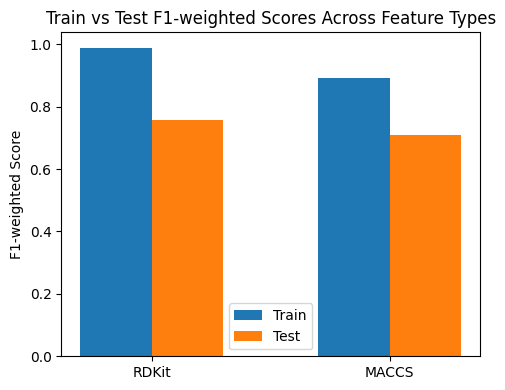

In [29]:
# Extract feature names
feature_types = list(all_results.keys())

# Extract F1 scores
f1_train = [all_results[feat]['results']['f1_weighted_train'] for feat in feature_types]
f1_test  = [all_results[feat]['results']['f1_weighted_test']  for feat in feature_types]

# Bar positions
x = np.arange(len(feature_types))
width = 0.3  # width of each bar

plt.figure(figsize=(5, 4))

# Bars
plt.bar(x - width/2, f1_train, width, label='Train')
plt.bar(x + width/2, f1_test,  width, label='Test')

# Labels & ticks
plt.ylabel("F1-weighted Score")
plt.title("Train vs Test F1-weighted Scores Across Feature Types")
plt.xticks(x, feature_types)
plt.legend()

plt.tight_layout()
plt.show()

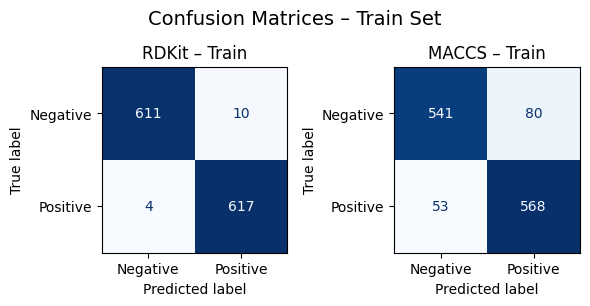

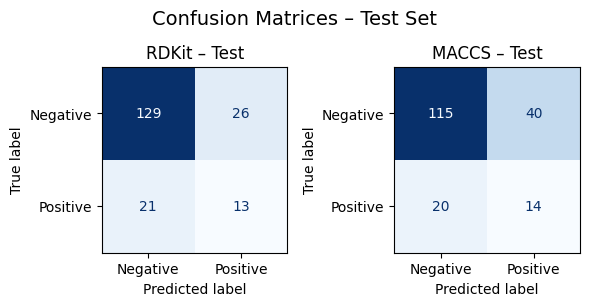

In [30]:
# 2. Confusion Matrix chart

# Function to build a sklearn-style confusion matrix
def build_cm(r, prefix):
    return np.array([
        [r[f"TrueNeg_{prefix}"],  r[f"FalsePos_{prefix}"]],
        [r[f"FalseNeg_{prefix}"], r[f"TruePos_{prefix}"]]
    ])

labels = ["Negative", "Positive"]
feature_types = list(all_results.keys())

# ========== FIGURE 1: TRAIN CONFUSION MATRICES ==========
fig, axes = plt.subplots(1, 2, figsize=(6, 3))

for ax, feat in zip(axes, feature_types):
    r = all_results[feat]["results"]
    cm = build_cm(r, "train")

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap="Blues", ax=ax, colorbar=False)
    ax.set_title(f"{feat} – Train")

fig.suptitle("Confusion Matrices – Train Set", fontsize=14)
plt.tight_layout()
plt.show()


# ========== FIGURE 2: TEST CONFUSION MATRICES ==========
fig, axes = plt.subplots(1, 2, figsize=(6, 3))

for ax, feat in zip(axes, feature_types):
    r = all_results[feat]["results"]
    cm = build_cm(r, "test")

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap="Blues", ax=ax, colorbar=False)
    ax.set_title(f"{feat} – Test")

fig.suptitle("Confusion Matrices – Test Set", fontsize=14)
plt.tight_layout()
plt.show()